# Регрессия на датасете Abalone

Возраст морского ушка определяется путем разрезания раковины через конус, ее окрашивания и подсчета количества колец под микроскопом — скучная и трудоемкая задача. Для прогнозирования возраста используются другие, более простые измерения. Для решения этой задачи может потребоваться дополнительная информация, такая как погодные условия и местоположение (следовательно, доступность пищи).

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
import shap

In [4]:
!pip install ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

df = X.copy()
df['Rings'] = y

## Обзор данных

In [6]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [8]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Промежуточные итоги

В датасете представленно 4177 записей. Пропущенныъ значений нет. Есть ровно 1 категориальный признак - Sex

### Категориальные признаки

In [9]:
print("Уникальные значения параметра Sex:")
print(X.Sex.unique())

Уникальные значения параметра Sex:
['M' 'F' 'I']


In [10]:
print(f"\nКоличество записей каждого класса:")
print(df['Sex'].value_counts())


Количество записей каждого класса:
Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64


### Дубликаты

In [11]:
df.duplicated().sum()

np.int64(0)

Делаем вывод что дубликатов нет

## Кодирование признака Sex

В датасете присутствует категориальный признак "Sex" с тремя возможными значениями: M (male), I (infant) и F (female). Для использования этой информации в алгоритмах машинного обучения требуется преобразовать категориальные значения в числовой формат. Для данной задачи был выбран OneHotEncoder.

In [13]:
df_encoded = df.copy()

In [15]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

sex_encoded = ohe.fit_transform(df_encoded[['Sex']])
one_hot_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(['Sex']))
df_encoded = pd.concat([df_encoded, one_hot_df], axis=1)

df_encoded = df_encoded.drop(['Sex'], axis=1)

In [17]:
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0.0,1.0,0.0


## Распределение данных

array([[<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Diameter'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Whole_weight'}>,
        <Axes: title={'center': 'Shucked_weight'}>,
        <Axes: title={'center': 'Viscera_weight'}>],
       [<Axes: title={'center': 'Shell_weight'}>,
        <Axes: title={'center': 'Rings'}>,
        <Axes: title={'center': 'Sex_F'}>],
       [<Axes: title={'center': 'Sex_I'}>,
        <Axes: title={'center': 'Sex_M'}>, <Axes: >]], dtype=object)

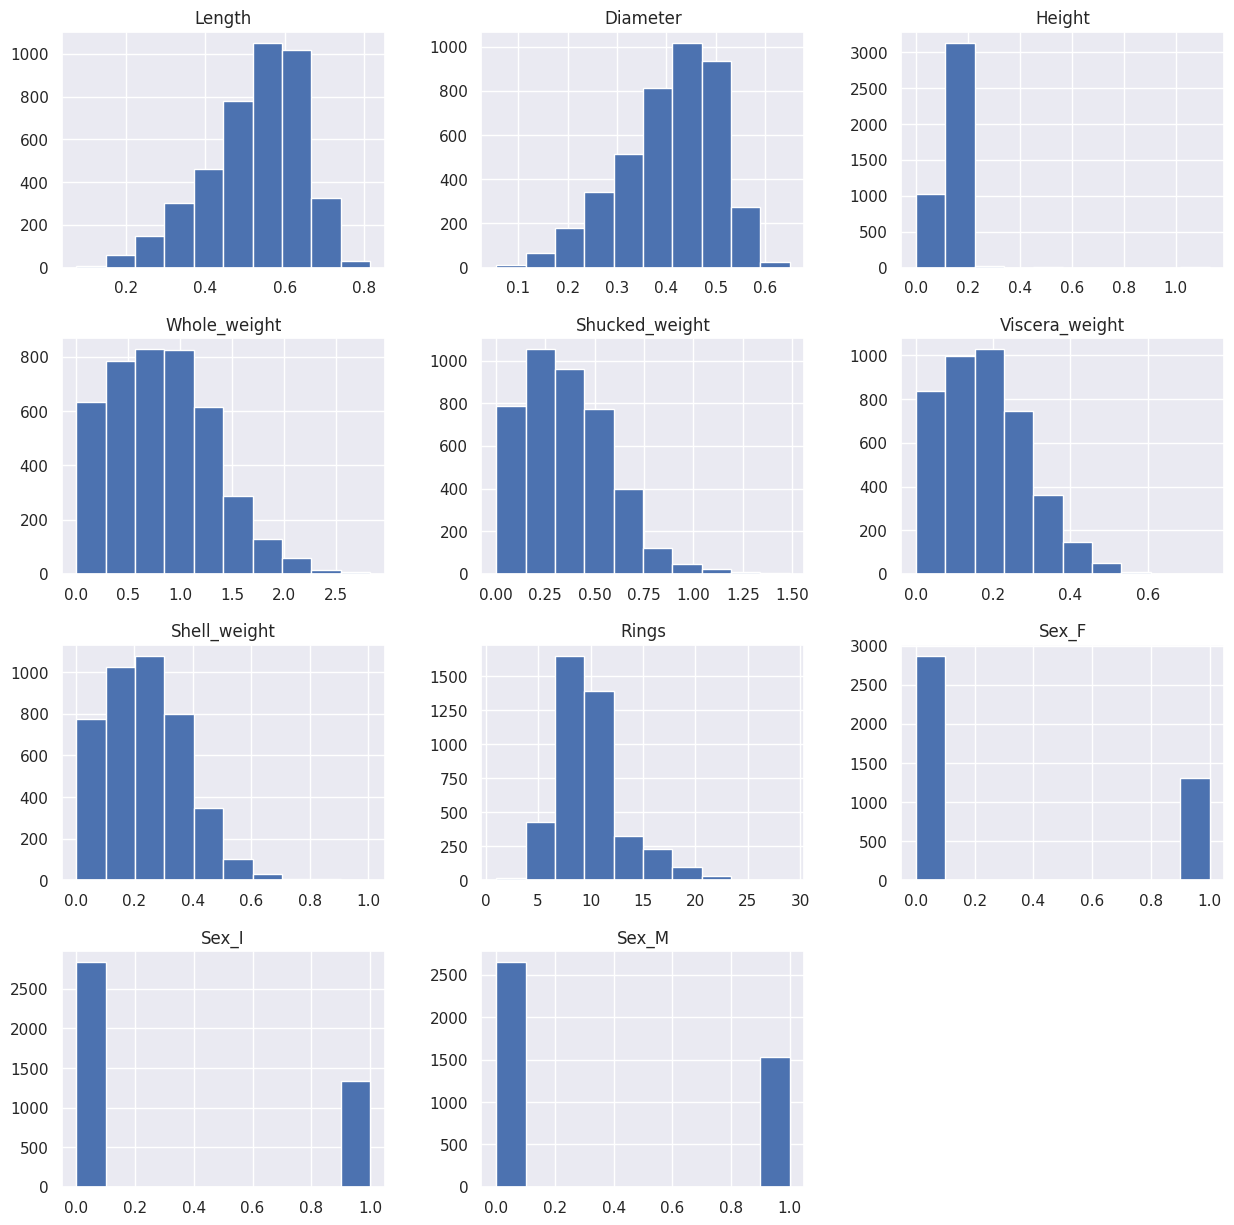

In [28]:
df_encoded.hist(figsize=(15,15))

По графику видно, что распределение данных по количеству колец несбалансированно, что может повлиять на дальнейшее обучение моделей.

## Корреляция данных

### Пирсона

In [18]:
corr = df_encoded.corr()

<Axes: >

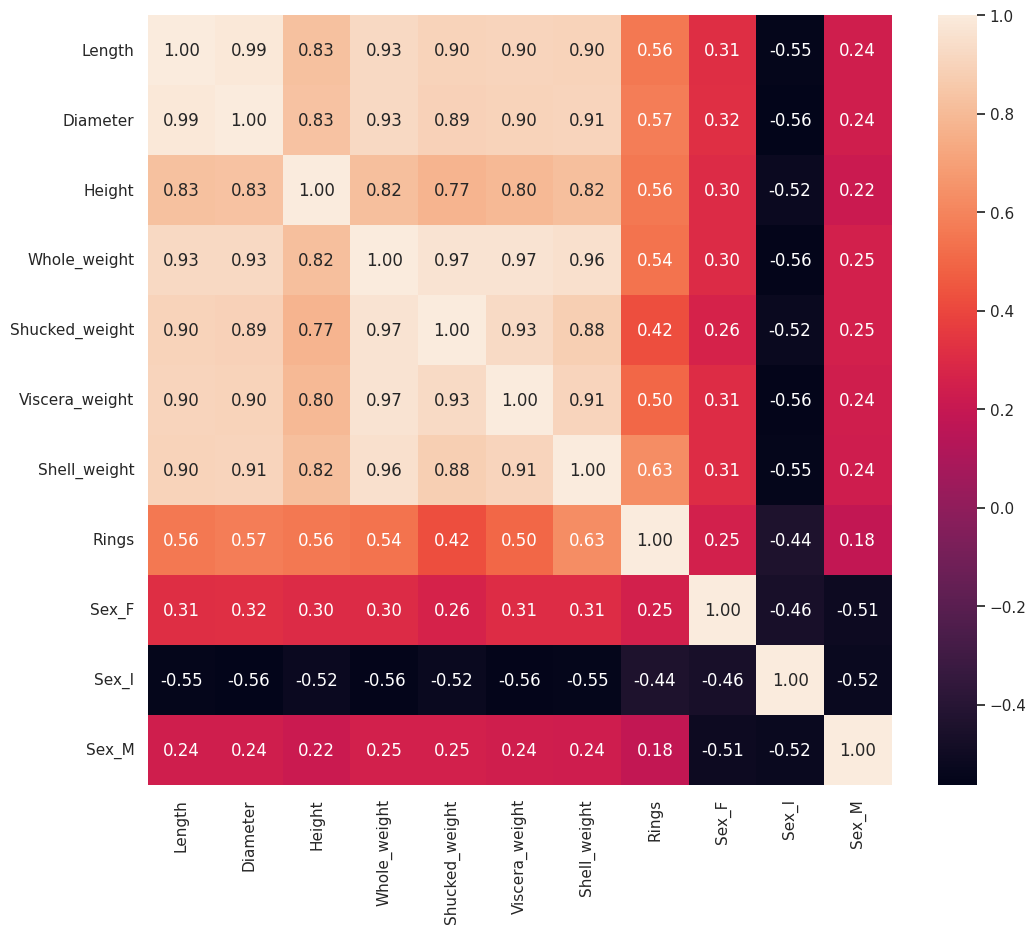

In [20]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(corr, annot=True, fmt='.2f')

In [21]:
print("\nКорреляция признаков с количеством колец:")
print(corr['Rings'].sort_values(ascending=False))


Корреляция признаков с количеством колец:
Rings             1.000000
Shell_weight      0.627574
Diameter          0.574660
Height            0.557467
Length            0.556720
Whole_weight      0.540390
Viscera_weight    0.503819
Shucked_weight    0.420884
Sex_F             0.250279
Sex_M             0.181831
Sex_I            -0.436063
Name: Rings, dtype: float64


### Спирмена

In [22]:
corr = df_encoded.corr(method='spearman')

<Axes: >

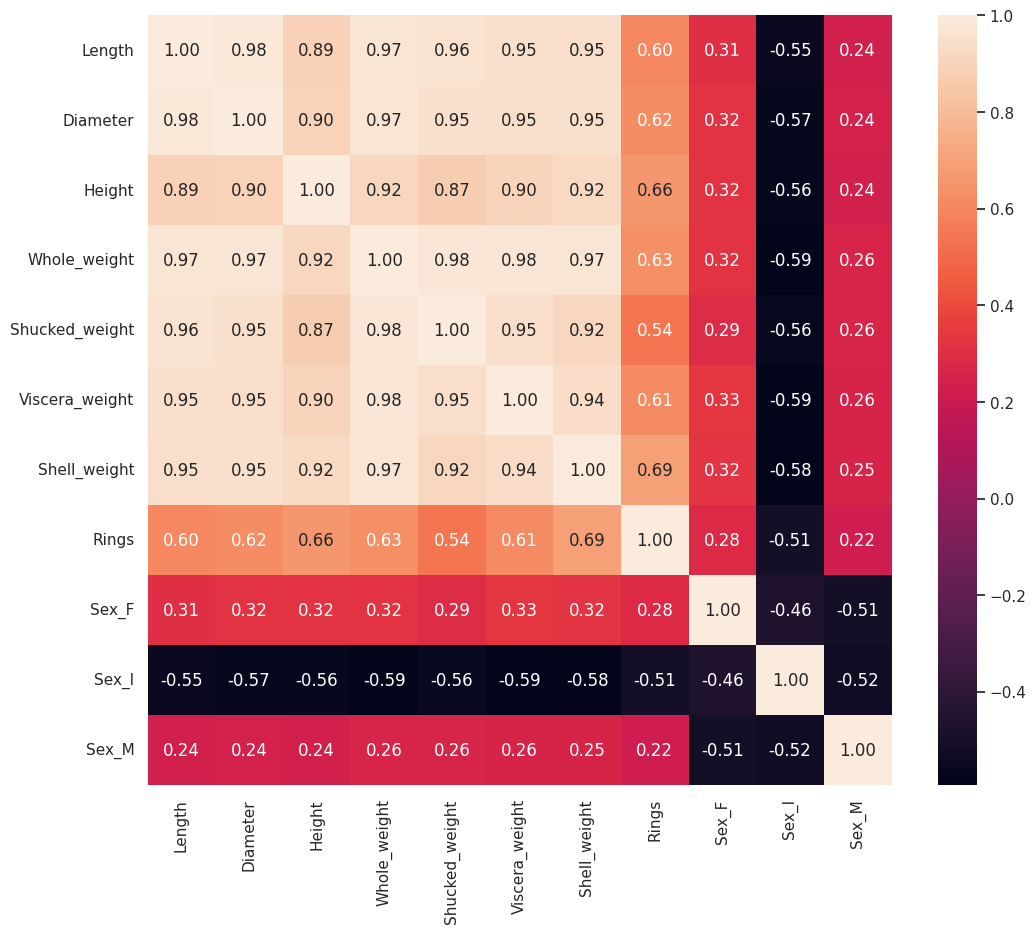

In [23]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(corr, annot=True, fmt='.2f')

In [24]:
print("\nКорреляция признаков с количеством колец:")
print(corr['Rings'].sort_values(ascending=False))


Корреляция признаков с количеством колец:
Rings             1.000000
Shell_weight      0.692475
Height            0.657716
Whole_weight      0.630832
Diameter          0.622895
Viscera_weight    0.614344
Length            0.604385
Shucked_weight    0.539420
Sex_F             0.283812
Sex_M             0.218739
Sex_I            -0.507429
Name: Rings, dtype: float64


### Кендела

In [25]:
corr = df_encoded.corr(method='kendall')

<Axes: >

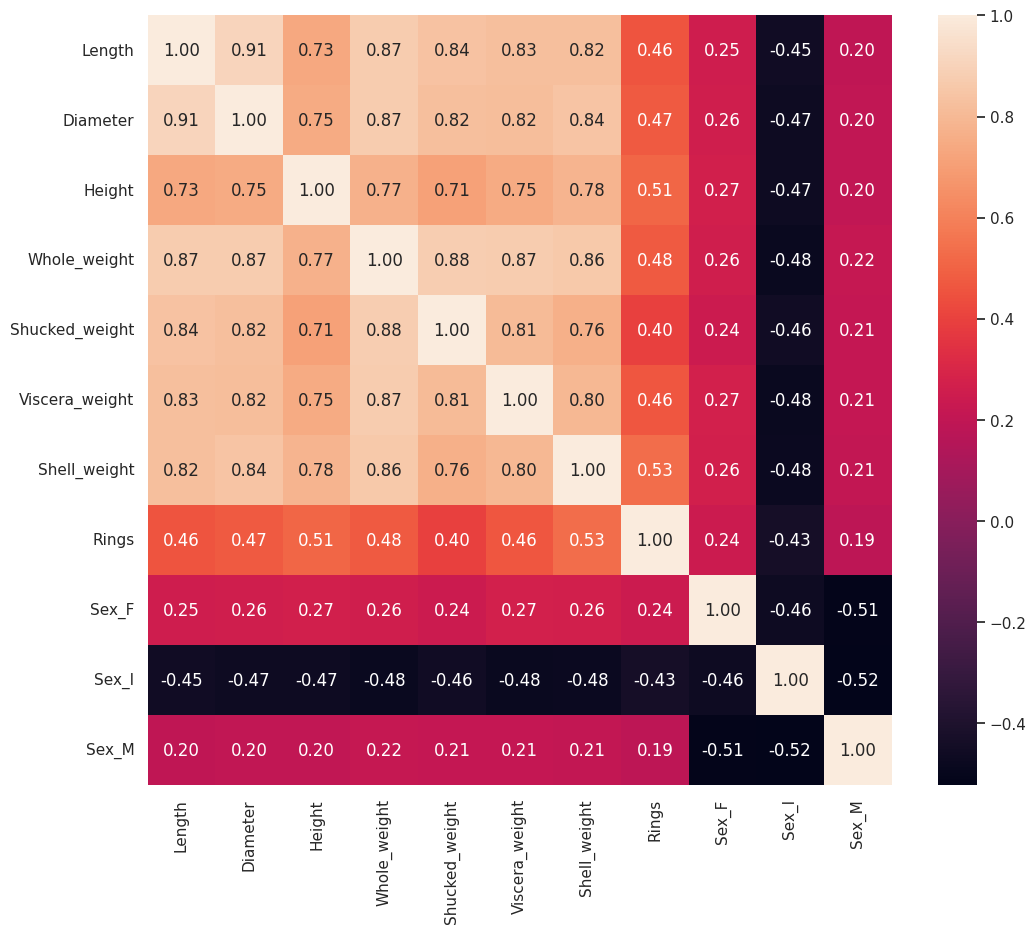

In [26]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(corr, annot=True, fmt='.2f')

In [27]:
print("\nКорреляция признаков с количеством колец:")
print(corr['Rings'].sort_values(ascending=False))


Корреляция признаков с количеством колец:
Rings             1.000000
Shell_weight      0.534644
Height            0.509357
Whole_weight      0.476360
Diameter          0.474094
Viscera_weight    0.461339
Length            0.457260
Shucked_weight    0.399137
Sex_F             0.243213
Sex_M             0.187449
Sex_I            -0.434843
Name: Rings, dtype: float64


### Выводы
По всем трем вариантам расчета корреляции можно сделать вывод что наиболее сильной связью количество колец обладает с параметром веса раковины.

Так же обратной связью количество колец обладает с параметром пола "Младенец".

## Анализ важности признаков

In [29]:
x = df_encoded.drop(columns=['Rings'])
y = df_encoded['Rings']

### GradientBoosting

In [53]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=43)
gb.fit(x, y)

GradientBoostingRegressor(random_state=43)

In [54]:
res = permutation_importance(gb, x, y, n_repeats=10, n_jobs=-1, random_state=35)

In [55]:
ir = res.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res.importances_mean[i]:.3f} std {res.importances_std[i]:.3f}')

Shucked_weight: 1.327 std 0.018
Shell_weight: 0.853 std 0.011
Whole_weight: 0.238 std 0.009
Height: 0.083 std 0.004
Sex_I: 0.029 std 0.002
Diameter: 0.029 std 0.002
Viscera_weight: 0.021 std 0.002
Length: 0.017 std 0.001
Sex_F: 0.001 std 0.000
Sex_M: 0.000 std 0.000


#### Вывод

Для RandomForest наиболее важными признаками оказались вес ракушки и вес мяса

### Lasso

In [44]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [45]:
lasso = Lasso(alpha=0.01, max_iter=1000, random_state=43)
lasso.fit(x_scaled, y)

Lasso(alpha=0.01, random_state=43)

In [46]:
res = permutation_importance(lasso, x_scaled, y, n_repeats=10, n_jobs=-1, random_state=35)

In [47]:
ir = res.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res.importances_mean[i]:.3f} std {res.importances_std[i]:.3f}')

Shucked_weight: 2.678 std 0.024
Whole_weight: 1.701 std 0.028
Shell_weight: 0.524 std 0.013
Diameter: 0.191 std 0.005
Viscera_weight: 0.098 std 0.003
Height: 0.039 std 0.003
Sex_I: 0.030 std 0.002
Sex_M: 0.000 std 0.000
Sex_F: 0.000 std 0.000
Length: 0.000 std 0.000


#### Вывод

Для модели Lasso наиболее значимыми признаками оказались вес ракушки и вес мяса.

## Обучение моделей

Так как данные несбалансированны воспользуемся стратификацией

In [51]:
y_bins = pd.qcut(y, q=3, labels=False)
y_bins.value_counts()

,count
Rings,
1,1810
0,1407
2,960


### GradientBoosting на всех признаках

In [96]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y_bins
)

#### Подбор оптимальных параметров

In [61]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

gb = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


#### Обучение

In [65]:
gb_all = GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=100, random_state=42)

gb_all.fit(x_train, y_train)
y_pred = gb_all.predict(x_test)

gb_all_mape = mean_absolute_percentage_error(y_test, y_pred)
gb_all_mse = mean_squared_error(y_test, y_pred)

In [66]:
print('GradientBoosting MAPE = ' + str(gb_all_mape))
print('GradientBoosting MSE = ' + str(gb_all_mse))

GradientBoosting MAPE = 0.15304611092923623
GradientBoosting MSE = 4.833107710800791


##### SHAP

In [70]:
gb_full_explainer = shap.Explainer(gb_all)
gb_full_shap_values = gb_full_explainer(x_test)
shap.initjs()

### GradientBoosting на коррелирующих признаках

#### Подбор оптимальных параметров

In [73]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

gb = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    gb,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train[['Shucked_weight', 'Shell_weight']], y_train)
print(f"Лучшие параметры: {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


#### Обучение

In [75]:
gb_correlated = GradientBoostingRegressor(learning_rate=0.05, max_depth=3, n_estimators=200, random_state=42)

gb_correlated.fit(x_train[['Shucked_weight', 'Shell_weight']], y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [76]:
y_pred = gb_correlated.predict(x_test[['Shucked_weight', 'Shell_weight']])

gb_correlated_mape = mean_absolute_percentage_error(y_test, y_pred)
gb_correlated_mse = mean_squared_error(y_test, y_pred)

In [92]:
print('GradientBoosting MAPE = ' + str(gb_correlated_mape))
print('GradientBoosting MSE = ' + str(gb_correlated_mse))

GradientBoosting MAPE = 0.1608127551237477
GradientBoosting MSE = 5.168969066736079


##### SHAP

In [97]:
gb_correlated_explainer = shap.Explainer(gb_correlated)
gb_correlated_shap_values = gb_correlated_explainer(x_test[['Shucked_weight', 'Shell_weight']])
shap.initjs()

### Lasso на всех признаках

In [79]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [100]:
x_train_scaled, x_test_scaled, y_train_s, y_test_s = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y_bins
)

#### Подбор оптимальных параметров

In [101]:
grid_lasso = LassoCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)

grid_lasso.fit(x_train_scaled, y_train_s)
print(f"Лучшие параметры: {grid_lasso.alpha_}")

Лучшие параметры: 0.01


#### Обучение

In [102]:
lasso = Lasso(alpha=0.01)
lasso.fit(x_train_scaled, y_train_s)

Lasso(alpha=0.01)

In [103]:
y_pred = lasso.predict(x_test_scaled)
lasso_all_mape = mean_absolute_percentage_error(y_test_s, y_pred)
lasso_all_mse = mean_squared_error(y_test_s, y_pred)

In [104]:
print('Lasso MAPE = ' + str(lasso_all_mape))
print('Lasso MSE = ' + str(lasso_all_mse))

Lasso MAPE = 0.16293492007317412
Lasso MSE = 4.926863735816288


### Lasso на коррелирующих признаках

#### Подбор оптимальных параметров

In [107]:
x_train_scaled_df = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,  # Сохраняем имена колонок
    index=x_train.index
)

In [108]:
grid_lasso = LassoCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)

grid_lasso.fit(x_train_scaled_df, y_train_s)
print(f"Лучшие параметры: {grid_lasso.alpha_}")

Лучшие параметры: 0.01


#### Обучение

In [109]:
lasso_correlated = Lasso(alpha=0.01)
lasso_correlated.fit(x_train_scaled_df, y_train_s)

Lasso(alpha=0.01)

In [110]:
y_pred = lasso_correlated.predict(x_test_scaled)
lasso_correlated_mape = mean_absolute_percentage_error(y_test_s, y_pred)
lasso_correlated_mse = mean_squared_error(y_test_s, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [112]:
print('Lasso MAPE = ' + str(lasso_correlated_mape))
print('Lasso MSE = ' + str(lasso_correlated_mse))

Lasso MAPE = 0.16293492007317412
Lasso MSE = 4.926863735816288


## Результаты

In [113]:
print('GradientBoosting на всех признаках MAPE = ' + str(gb_all_mape))
print('GradientBoosting на коррелирующих признаках MAPE = ' + str(gb_correlated_mape))
print('Lasso на всех признаках MAPE = ' + str(lasso_all_mape))
print('Lasso на коррелирующих признаках MAPE = ' + str(lasso_correlated_mape))

GradientBoosting на всех признаках MAPE = 0.15304611092923623
GradientBoosting на коррелирующих признаках MAPE = 0.1608127551237477
Lasso на всех признаках MAPE = 0.16293492007317412
Lasso на коррелирующих признаках MAPE = 0.16293492007317412


In [114]:
print('GradientBoosting на всех признаках MSE = ' + str(gb_all_mse))
print('GradientBoosting на коррелирующих признаках MSE = ' + str(gb_correlated_mse))
print('Lasso на всех признаках MSE = ' + str(lasso_all_mse))
print('Lasso на коррелирующих признаках MSE = ' + str(lasso_correlated_mse))

GradientBoosting на всех признаках MSE = 4.833107710800791
GradientBoosting на коррелирующих признаках MSE = 5.168969066736079
Lasso на всех признаках MSE = 4.926863735816288
Lasso на коррелирующих признаках MSE = 4.926863735816288


По ошибке MAPE значения у всех вариантов достаточно близки, но тем не менее GradientBoosting по всем признакам имеет наименьшие обе ошибки.

## Анализ GradientBoosting

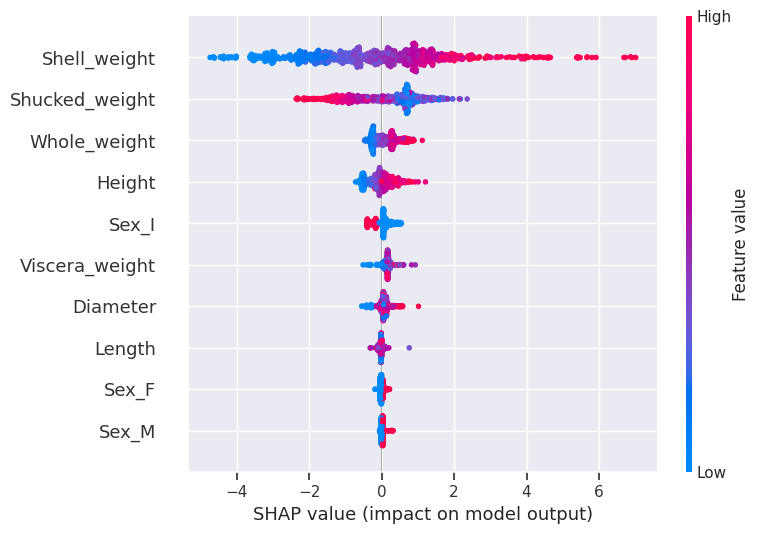

In [116]:
shap.summary_plot(gb_full_shap_values, x_test)

Масса раковины Shell_weight оказывает наибольшее влияние.
На втором месте Масса мяса Shucked_weight.
Остлаьные же признаки, судя по данному графику имеют незначительное влияние на количество колец.